In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

##### Carga del dataset

In [5]:
train = pd.read_csv('../../../data/house-prices-advanced/train.csv')
test = pd.read_csv('../../../data/house-prices-advanced/test.csv')

##### Identificacion de variables numericas y categoricas

Análisis inicial de variables numéricas:
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904   

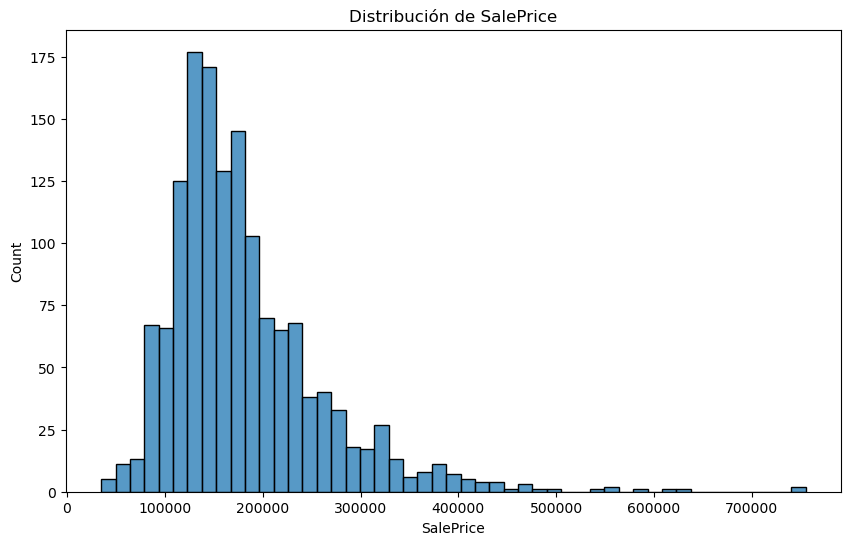

In [8]:
numeric_features = train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = train.select_dtypes(include=['object']).columns
print("Análisis inicial de variables numéricas:")
print(train[numeric_features].describe())

#Distribucion de la variable precio
plt.figure(figsize=(10, 6))
sns.histplot(train['SalePrice'])
plt.title('Distribución de SalePrice')
plt.show()

##### Exploracion y preprocesamiento


Variables con mayor asimetría:
MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
dtype: float64


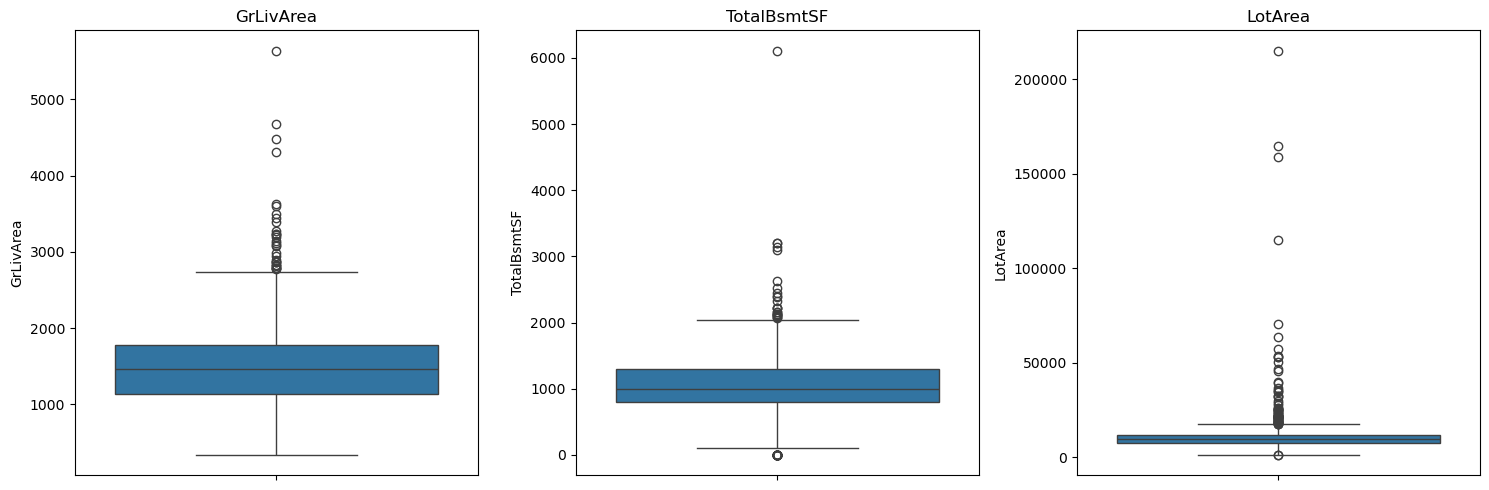

In [9]:
# Análisis de asimetría para variables numéricas
skewness = train[numeric_features].skew()
print("\nVariables con mayor asimetría:")
print(skewness[abs(skewness) > 1].sort_values(ascending=False))

# Identificación de outliers usando boxplots para variables importantes
important_features = ['GrLivArea', 'TotalBsmtSF', 'LotArea']
plt.figure(figsize=(15, 5))
for i, feature in enumerate(important_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=train[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

##### Transformacion logaritmica y polinomica de variables sesgadas y SalesPrice

In [11]:
# Transformación logarítmica de SalePrice y variables sesgadas
train['SalePrice_Log'] = np.log1p(train['SalePrice'])
skewed_features = skewness[abs(skewness) > 1].index
for feature in skewed_features:
    if feature != 'SalePrice' and feature in train.columns:
        train[f'{feature}_Log'] = np.log1p(train[feature])

# Creación de variables polinómicas
for feature in important_features:
    train[f'{feature}_Squared'] = train[feature] ** 2
    train[f'{feature}_Cubed'] = train[feature] ** 3

# Estandarización de variables numéricas
scaler = StandardScaler()
numeric_cols = [col for col in train.columns if train[col].dtype in ['int64', 'float64']]
train_scaled = train.copy()
train_scaled[numeric_cols] = scaler.fit_transform(train[numeric_cols])

# Transformación logarítmica de SalePrice y variables sesgadas
train['SalePrice_Log'] = np.log1p(train['SalePrice'])
skewed_features = skewness[abs(skewness) > 1].index
for feature in skewed_features:
    if feature != 'SalePrice' and feature in train.columns:
        train[f'{feature}_Log'] = np.log1p(train[feature])

# Creación de variables polinómicas
for feature in important_features:
    train[f'{feature}_Squared'] = train[feature] ** 2
    train[f'{feature}_Cubed'] = train[feature] ** 3

# Estandarización de variables numéricas
scaler = StandardScaler()
numeric_cols = [col for col in train.columns if train[col].dtype in ['int64', 'float64']]
train_scaled = train.copy()
train_scaled[numeric_cols] = scaler.fit_transform(train[numeric_cols])

##### Evaluacion de transformaciones

In [12]:
X = train[important_features]
y = train['SalePrice']

X_transformed = train[[col for col in train.columns if any(feat in col for feat in important_features)]]
y_transformed = train['SalePrice_Log']

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_trans, X_test_trans, y_train_trans, y_test_trans = train_test_split(X_transformed, y_transformed, test_size=0.2, random_state=42)

# Modelo sin transformaciones
model_original = LinearRegression()
model_original.fit(X_train, y_train)
y_pred_original = model_original.predict(X_test)
rmse_original = np.sqrt(mean_squared_error(y_test, y_pred_original))
r2_original = r2_score(y_test, y_pred_original)

# Modelo con transformaciones
model_transformed = LinearRegression()
model_transformed.fit(X_train_trans, y_train_trans)
y_pred_trans = model_transformed.predict(X_test_trans)
y_pred_trans = np.expm1(y_pred_trans)  # Revertir transformación logarítmica
y_test_untrans = np.expm1(y_test_trans)
rmse_transformed = np.sqrt(mean_squared_error(y_test_untrans, y_pred_trans))
r2_transformed = r2_score(y_test_untrans, y_pred_trans)

# 5. Interpretación de resultados
print("\nResultados del modelo:")
print(f"Modelo Original - RMSE: {rmse_original:.2f}, R2: {r2_original:.4f}")
print(f"Modelo Transformado - RMSE: {rmse_transformed:.2f}, R2: {r2_transformed:.4f}")


Resultados del modelo:
Modelo Original - RMSE: 49796.58, R2: 0.6767
Modelo Transformado - RMSE: 49280.83, R2: 0.6834


##### Interpretacion del modelo


Resultados del modelo:
Modelo Original - RMSE: 49796.58, R2: 0.6767
Modelo Transformado - RMSE: 49280.83, R2: 0.6834


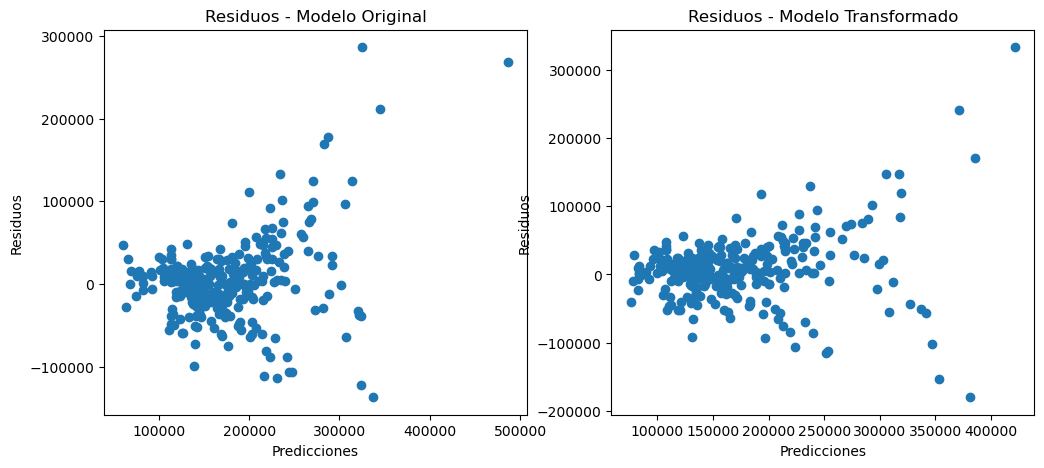

In [13]:
print("\nResultados del modelo:")
print(f"Modelo Original - RMSE: {rmse_original:.2f}, R2: {r2_original:.4f}")
print(f"Modelo Transformado - RMSE: {rmse_transformed:.2f}, R2: {r2_transformed:.4f}")

# Visualización de residuos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_original, y_test - y_pred_original)
plt.title('Residuos - Modelo Original')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')

plt.subplot(1, 2, 2)
plt.scatter(y_pred_trans, y_test_untrans - y_pred_trans)
plt.title('Residuos - Modelo Transformado')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.show()

##### Importacion de caracteristicas

In [14]:
importance_orig = pd.DataFrame({
    'feature': X.columns,
    'importance': abs(model_original.coef_)
})
importance_trans = pd.DataFrame({
    'feature': X_transformed.columns,
    'importance': abs(model_transformed.coef_)
})

print("\nImportancia de características - Modelo Original:")
print(importance_orig.sort_values('importance', ascending=False))
print("\nImportancia de características - Modelo Transformado:")
print(importance_trans.sort_values('importance', ascending=False))


Importancia de características - Modelo Original:
       feature  importance
0    GrLivArea   77.892212
1  TotalBsmtSF   61.492224
2      LotArea    0.239740

Importancia de características - Modelo Transformado:
                feature    importance
3           LotArea_Log  2.721287e-02
4       TotalBsmtSF_Log  1.060976e-02
2             GrLivArea  6.792563e-04
1           TotalBsmtSF  4.955649e-04
5         GrLivArea_Log  4.386922e-06
0               LotArea  3.799105e-06
6     GrLivArea_Squared  4.811868e-08
8   TotalBsmtSF_Squared  3.156231e-08
10      LotArea_Squared  4.449271e-11
7       GrLivArea_Cubed  9.417159e-12
9     TotalBsmtSF_Cubed  5.750001e-12
11        LotArea_Cubed  1.365499e-16
